# Hands-on Logging and Tracking Model using MLflow

## Training and Testing Regression Model

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Download Data IHSG
data = yf.download("^JKSE", start="2020-01-01", end="2026-01-31")
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open    Volume
Ticker            ^JKSE        ^JKSE        ^JKSE        ^JKSE     ^JKSE
Date                                                                    
2020-01-02  6283.581055  6317.013184  6263.675781  6313.127930  33043700
2020-01-03  6323.465820  6323.465820  6287.706055  6306.187012  44625300
2020-01-06  6257.402832  6300.436035  6252.634766  6293.499023  41421300
2020-01-07  6279.346191  6284.892090  6246.128906  6272.220215  39441600
2020-01-08  6225.686035  6250.122070  6218.129883  6248.442871  44622600


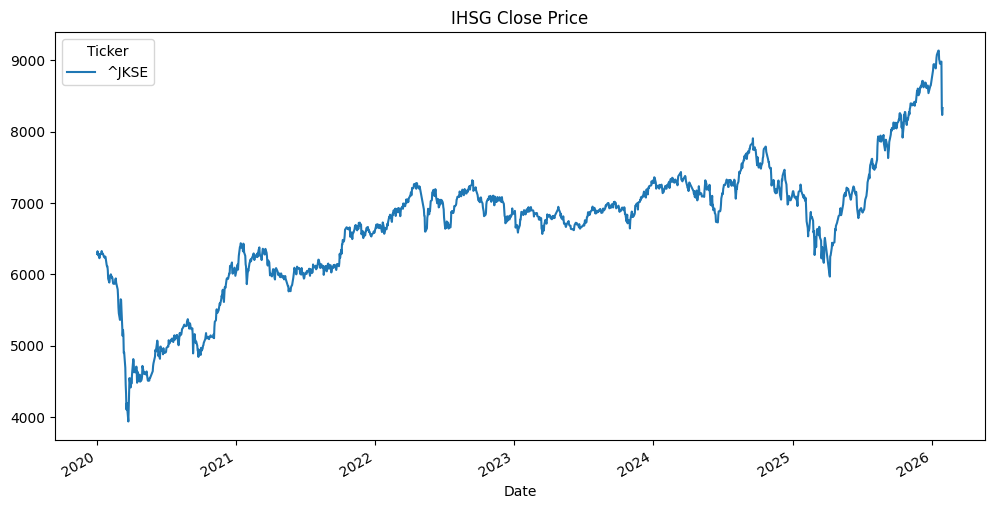

In [4]:
# Visualisasi
data['Close'].plot(figsize=(12,6), title='IHSG Close Price')
plt.show()

In [5]:
def create_lag_features(df, n_lags=30):
    X, y = [], []
    values = df['Close'].values
    for i in range(len(values)-n_lags):
        X.append(values[i:i+n_lags])
        y.append(values[i+n_lags])
    # pastikan hasilnya 2D, bukan 3D
    return np.array(X).reshape(-1, n_lags), np.array(y)

X, y = create_lag_features(data, n_lags=30)
print("Shape X:", X.shape, "Shape y:", y.shape)

Shape X: (1437, 30) Shape y: (1437, 1)


In [12]:
# --- Convert X to DataFrame (important for MLflow)
feature_columns = [f"lag_{i+1}" for i in range(30)]
df_features = pd.DataFrame(X, columns=feature_columns)
df_features['target'] = y

In [9]:
import os

In [10]:
os.environ['MLFLOW_TRACKING_USERNAME'] = 'admin'
os.environ['MLFLOW_TRACKING_PASSWORD'] = 'mlflowadmin123'

In [13]:
# --- Log Feature Set to MLflow
mlflow.set_tracking_uri("https://5000-firebase-python-mlops-01-1771598143149.cluster-iktsryn7xnhpexlu6255bftka4.cloudworkstations.dev")
mlflow.set_experiment("TimeSeries_Features")

with mlflow.start_run(run_name="IHSG_LagFeatures_v1"):
    # Log feature parameters
    mlflow.log_param("n_lags", 30)
    mlflow.log_param("num_samples", len(df_features))

    # Log feature dataset to registry
    feature_dataset = mlflow.data.from_pandas(df_features, name="IHSG_LagFeatureSet_v1")
    mlflow.log_input(feature_dataset, context="training_features")

    print("Feature set logged successfully to MLflow.")

Feature set logged successfully to MLflow.
🏃 View run IHSG_LagFeatures_v1 at: https://5000-firebase-python-mlops-01-1771598143149.cluster-iktsryn7xnhpexlu6255bftka4.cloudworkstations.dev/#/experiments/1/runs/81fc16c5bb8c4e3197355b950609ab1d
🧪 View experiment at: https://5000-firebase-python-mlops-01-1771598143149.cluster-iktsryn7xnhpexlu6255bftka4.cloudworkstations.dev/#/experiments/1


In [17]:
logged_run = mlflow.get_run('81fc16c5bb8c4e3197355b950609ab1d')
logged_dataset = logged_run.inputs.dataset_inputs[0].dataset

In [18]:
logged_dataset

<Dataset: digest='5c331e50', name='IHSG_LagFeatureSet_v1', profile='{"num_rows": 1437, "num_elements": 44547}', schema=('{"mlflow_colspec": [{"type": "double", "name": "lag_1", "required": true}, '
 '{"type": "double", "name": "lag_2", "required": true}, {"type": "double", '
 '"name": "lag_3", "required": true}, {"type": "double", "name": "lag_4", '
 '"required": true}, {"type": "double", "name": "lag_5", "required": true}, '
 '{"type": "double", "name": "lag_6", "required": true}, {"type": "double", '
 '"name": "lag_7", "required": true}, {"type": "double", "name": "lag_8", '
 '"required": true}, {"type": "double", "name": "lag_9", "required": true}, '
 '{"type": "double", "name": "lag_10", "required": true}, {"type": "double", '
 '"name": "lag_11", "required": true}, {"type": "double", "name": "lag_12", '
 '"required": true}, {"type": "double", "name": "lag_13", "required": true}, '
 '{"type": "double", "name": "lag_14", "required": true}, {"type": "double", '
 '"name": "lag_15", "re

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

/home/user/python-mlops-02/.venv/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [7]:
joblib.dump(model, 'ihsg_model_reg.pkl')
print('Model saved as ihsg_model_reg.pkl')

Model saved as ihsg_model_reg.pkl


In [22]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('RMSE:', rmse)

RMSE: 446.26519160238513


In [8]:
import mlflow
import mlflow.sklearn

In [19]:
# Set tracking server remote
mlflow.set_tracking_uri("https://5000-firebase-python-mlops-01-1771598143149.cluster-iktsryn7xnhpexlu6255bftka4.cloudworkstations.dev")
mlflow.set_experiment("IHSG_Experiment_Remote")

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1771770777558, experiment_id='2', last_update_time=1771770777558, lifecycle_stage='active', name='IHSG_Experiment_Remote', tags={}, workspace='default'>

In [20]:
# Buat contoh input
input_example = pd.DataFrame(X_test[:5], columns=[f"f{i}" for i in range(X_test.shape[1])])

In [23]:
# Logging ke remote server
with mlflow.start_run(run_name="RandomForestRegressor_v1"):
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_metric("rmse", rmse)

    # Log model ke server remote
    mlflow.sklearn.log_model(
        sk_model=model,
        name="model",
        registered_model_name="IhsgRegressor",
        input_example=input_example
    )

2026/02/22 22:32:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/user/python-mlops-02/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/user/python-mlops-02/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
Registered model 'IhsgRegressor' already exists. Creating a new version of this model...
2026/02/22 22:32:17 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for

🏃 View run RandomForestRegressor_v1 at: https://5000-firebase-python-mlops-01-1771598143149.cluster-iktsryn7xnhpexlu6255bftka4.cloudworkstations.dev/#/experiments/2/runs/74ab665de0fc49b89ee279f217e2ec29
🧪 View experiment at: https://5000-firebase-python-mlops-01-1771598143149.cluster-iktsryn7xnhpexlu6255bftka4.cloudworkstations.dev/#/experiments/2


## Implementation of Registerred Regression Model

In [24]:
# Load model versi Production (atau versi tertentu)
model_remote = mlflow.pyfunc.load_model("models:/IhsgRegressor/2")

In [25]:
# Fetch the latest data for IHSG
latest_data = yf.download("^JKSE", period="60d")

# Extract the 'Close' prices and convert to a list
latest_30_array = latest_data['Close'].tail(30).to_numpy()
latest_ls = [a for a in latest_30_array]

# Prepare the latest 30 days data as input for prediction
current_input_latest = np.array(latest_ls).reshape(1, -1)

# Predict the next 15 days using the loaded model
predicted_prices_latest = []
current_predict_input = current_input_latest

for _ in range(15):
    # Convert the NumPy array to a DataFrame with expected column names
    input_df = pd.DataFrame(current_predict_input, columns=[f"f{i}" for i in range(current_predict_input.shape[1])])

    # Predict the next day's price
    next_price = model_remote.predict(input_df)[0]
    predicted_prices_latest.append(next_price)

    # Update the input sequence by removing the oldest data point and adding the new prediction
    current_predict_input = np.roll(current_predict_input, -1)
    current_predict_input[0, -1] = next_price

# Generate dates for the next 15 days
last_date = latest_data.index[-1]
predicted_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=15, freq='D')

# Create a DataFrame to display the results
predicted_results_df = pd.DataFrame({
    'Date': predicted_dates,
    'Predicted Close Price': predicted_prices_latest
})

print("Predicted IHSG closing prices for the next 15 days:")
display(predicted_results_df)

[*********************100%***********************]  1 of 1 completed
/home/user/python-mlops-02/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/user/python-mlops-02/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/user/python-mlops-02/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/user/python-mlops-02/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/home/user/python-mlops-02/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning

Predicted IHSG closing prices for the next 15 days:


,Date,Predicted Close Price
0,2026-02-21,7751.772666
1,2026-02-22,7731.680264
2,2026-02-23,7723.700703
3,2026-02-24,7700.464600
4,2026-02-25,7676.314033
5,2026-02-26,7612.876064
6,2026-02-27,7584.223623
7,2026-02-28,7578.046299
8,2026-03-01,7569.160117
9,2026-03-02,7570.112490


In [28]:
predicted_results_df.index = predicted_results_df.Date
predicted_results_df

,Date,Predicted Close Price
Date,,
2026-02-21,2026-02-21,7751.772666
2026-02-22,2026-02-22,7731.680264
2026-02-23,2026-02-23,7723.700703
2026-02-24,2026-02-24,7700.464600
2026-02-25,2026-02-25,7676.314033
2026-02-26,2026-02-26,7612.876064
2026-02-27,2026-02-27,7584.223623
2026-02-28,2026-02-28,7578.046299
2026-03-01,2026-03-01,7569.160117


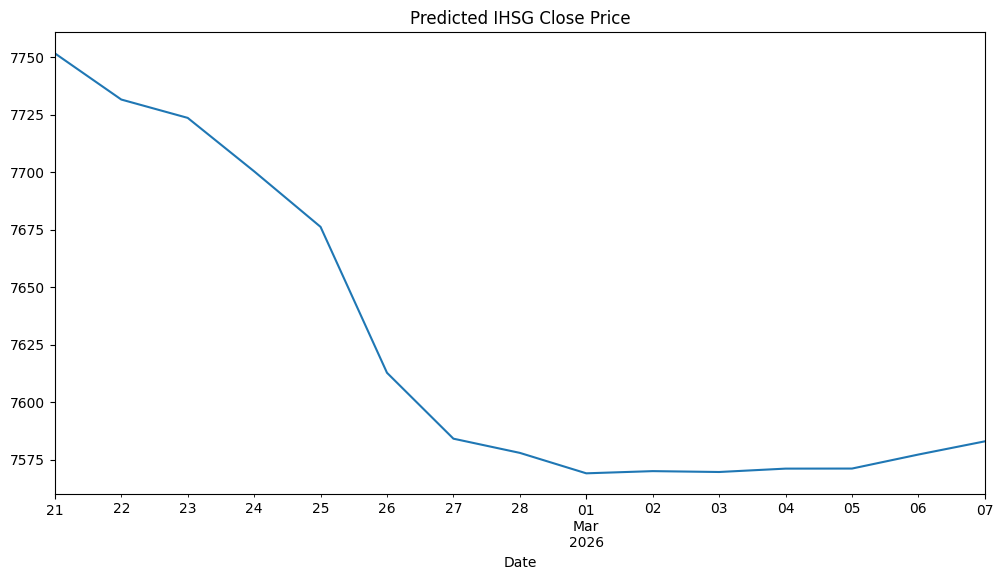

In [29]:
predicted_results_df['Predicted Close Price'].plot(figsize=(12,6), title='Predicted IHSG Close Price')
plt.show()